# **Importing Libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Embedding, Flatten

# Loading Dataset

In [3]:
df = pd.read_csv(
    "IMDB_Dataset.csv",
    encoding="latin-1",
    engine="python",
    on_bad_lines='skip'
)


print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
display(df.head())

Rows: 49942
Columns: 106


,review,sentiment,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105
0,One of the other reviewers has mentioned that ...,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A wonderful little production. <br /><br />The...,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,I thought this was a wonderful way to spend ti...,positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Basically there's a family where a little boy ...,negative,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Dataset Info & Statistics

In [4]:
display(df.info())
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49942 entries, 0 to 49941
Columns: 106 entries, review to Unnamed: 105
dtypes: object(106)
memory usage: 40.4+ MB


None

,review,sentiment,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 96,Unnamed: 97,Unnamed: 98,Unnamed: 99,Unnamed: 100,Unnamed: 101,Unnamed: 102,Unnamed: 103,Unnamed: 104,Unnamed: 105
count,49942,49940,300,282,264,244,222,206,194,180,...,1,1,1,1,1,1,1,1,1,1
unique,49525,300,281,266,246,224,208,194,183,162,...,1,1,1,1,1,1,1,1,1,1
top,Loved today's show!!! It was a variety and not...,negative,negative,positive,negative,negative,negative,negative,positive,negative,...,and how having too much power isn't good. Peop...,and are greedy,and the main villian,Muska,greatly shows this.<br /><br />All in all,Laputa: Castle In The Sky was a great film to ...,and is now improved for the most part. I am gl...,Disney has done a nice job on this dub and is ...,Castle In The Sky is still a great dub and is ...,positive
freq,5,24824,12,9,14,13,8,7,7,12,...,1,1,1,1,1,1,1,1,1,1


# Exploratory Data Analysis (EDA)

# Review Length Distribution

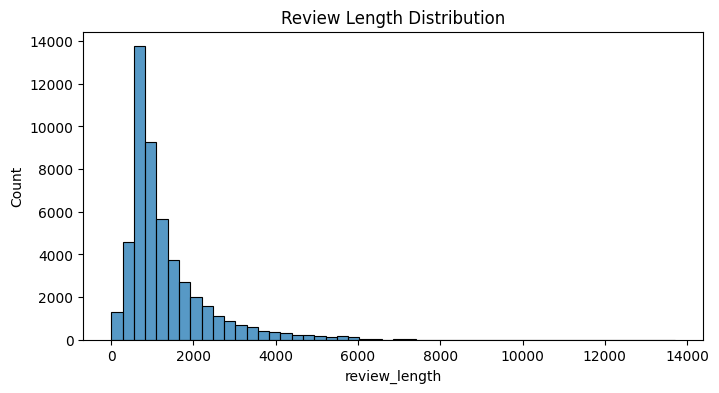

In [6]:
df['review_length'] = df['review'].apply(len)

plt.figure(figsize=(8,4))
sns.histplot(df['review_length'], bins=50)
plt.title("Review Length Distribution")
plt.show()


# Data Preprocessing

Separate Features & Labels

In [7]:
X = df['review'].values
y = df['sentiment'].values

Encode Labels (Binary)

In [8]:
le = LabelEncoder()
y = le.fit_transform(y)
# positive -> 1, negative -> 0


# Text Tokenization & Padding

In [9]:
VOCAB_SIZE = 20000
EMBED_DIM = 128
MAX_LEN = 200


In [10]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(X)

sequences = tokenizer.texts_to_sequences(X)
padded_sequences = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')


# Train-Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    padded_sequences, y, test_size=0.2, random_state=42
)

# Model Architecture

In [12]:
model = Sequential()

model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN))
model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(1, activation='sigmoid'))


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2026-04-15 12:31:34.970743: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-15 12:31:34.971317: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-15 12:31:34.971324: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-15 12:31:34.972022: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-15 12:31:34.972678: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus 

# Compile Model

In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


# Training

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)


Epoch 1/20


2026-04-15 12:31:43.289743: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 72ms/step - accuracy: 3.1287e-05 - loss: -5772.5400 - val_accuracy: 0.0000e+00 - val_loss: -31003.5996
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.0000e+00 - loss: -39513.1914 - val_accuracy: 0.0000e+00 - val_loss: -74723.5625
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 89ms/step - accuracy: 0.0000e+00 - loss: -102886.1406 - val_accuracy: 0.0000e+00 - val_loss: -166382.8125
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.0000e+00 - loss: -191431.5938 - val_accuracy: 0.0000e+00 - val_loss: -249570.4844
Epoch 5/20
473/500 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - accuracy: 0.0000e+00 - loss: -270802.6115

# Training and Validation Loss

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


# Evaluation

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


# Predictions & Metrics

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = (y_pred > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes, target_names=['Negative', 'Positive']))


# Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()
